# EU Capital Markets Union — Simulation

**Model:** Behavioural general equilibrium with CPT households, Solow firms, and gravity-based information frictions.

**Structure:**
1. Imports and utils
2. Simulation functions (equilibrium + realisation)
3. SMM loss function
4. GP-Bayesian outer loop (calibration)
5. Example run with dummy parameters

---
## 1. Imports

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from tqdm import tqdm
from sklearn.metrics import r2_score

# Utils
from utils.v3.firm import (
    expected_tfp, realised_tfp, output, mpk,
    dividend, expected_dividend, capital_next_period,
    implied_return, tobins_q
)
from utils.v3.household import (
    reference_point, sigma_tilde, prospect_value,
    probability_weight, cpt_value, update_wealth, bilateral_positions
)
from utils.v3.information import compute_ln_omega

---
## 2. Simulation functions

In [2]:
def cpt_portfolio(r_implied_vec, r_0_vec, sigma_tilde_vec, w_prev, rho,
                  alpha_v=0.88, beta_v=0.88, lam=2.25,
                  gamma_plus=0.61, delta_minus=0.69):
    """
    Optimise CPT portfolio weights across N countries, then apply inertia.
    w = rho * w_star + (1 - rho) * w_prev
    """
    N = len(r_implied_vec)
    cpt_vals = np.array([
        cpt_value(r_implied_vec[j], r_0_vec[j], sigma_tilde_vec[j],
                  alpha_v, beta_v, lam, gamma_plus, delta_minus)
        for j in range(N)
    ])
    result = minimize(
        lambda w: -np.dot(w, cpt_vals),
        w_prev.copy(),
        jac=lambda w: -cpt_vals,
        method="SLSQP",
        bounds=[(0, 1)] * N,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
        options={"ftol": 1e-9, "maxiter": 500}
    )
    w_star = result.x
    w = rho * w_star + (1 - rho) * w_prev
    return w / w.sum(), w_star

In [3]:
def equilibrium_capital(A0, L, alpha, gamma, r_implied, delta,
                        K_lo=1e-4, K_hi=1e4):
    """
    Solve MPK(K) = r_implied + delta via Brent's method.
    """
    target = r_implied + delta
    f = lambda K: mpk(A0, K, L, alpha, gamma) - target
    if f(K_lo) * f(K_hi) > 0:
        raise ValueError(f"Brent bracket failed: f({K_lo})={f(K_lo):.4f}, f({K_hi})={f(K_hi):.4f}")
    return brentq(f, K_lo, K_hi, xtol=1e-9)

In [4]:
def market_clearing(W_vec, w_mat):
    """
    V_j = sum_i w_{i,j} * W_i
    """
    return w_mat.T @ W_vec

In [5]:
def inner_equilibrium(K_vec, K_vec_prev, W_vec, w_mat, w_mat_prev,
                      omega_mat, params, max_iter=100, tol=1e-6):
    """
    Iterate CPT portfolio choice <-> firm capital adjustment until
    MPK_j = r_implied_j + delta for all j.

    Returns K_vec, w_mat, V_vec, r_vec, Q_vec, n_iter
    """
    N     = len(K_vec)
    K_vec = K_vec.copy()
    w_mat = w_mat.copy()

    A0_vec    = params["A0_vec"]
    L_vec     = params["L_vec"]
    s_vec     = params["s_vec"]
    sigma_vec = params["sigma_vec"]
    alpha     = params["alpha"]
    gamma     = params["gamma"]
    delta     = params["delta"]
    rho       = params["rho"]
    phi_0     = params["phi_0"]

    for iteration in range(max_iter):

        # Market clearing
        V_vec = market_clearing(W_vec, w_mat)

        # Implied returns
        r_vec = np.array([
            implied_return(
                expected_dividend(A0_vec[j], K_vec[j], L_vec[j], s_vec[j], alpha, gamma),
                K_vec[j], K_vec_prev[j], V_vec[j]
            ) for j in range(N)
        ])
        
        # Safeguard: clip returns to reasonable range to avoid numerical issues
        r_vec = np.clip(r_vec, a_min=-0.5, a_max=2.0)

        # Friction-adjusted volatilities
        sigma_tilde_mat = np.array([
            [sigma_tilde(sigma_vec[j], phi_0, omega_mat[i, j]) for j in range(N)]
            for i in range(N)
        ])

        # CPT portfolio per household
        w_mat_new = np.zeros((N, N))
        for i in range(N):
            w_mat_new[i], _ = cpt_portfolio(
                r_vec, r_vec, sigma_tilde_mat[i], w_mat_prev[i], rho
            )

        # Firm capital adjustment
        K_vec_new = np.array([
            equilibrium_capital(A0_vec[j], L_vec[j], alpha, gamma, r_vec[j], delta, 
                               K_lo=1e-10, K_hi=1e8)  # Wider brackets
            for j in range(N)
        ])

        # Convergence
        mpk_vec = np.array([mpk(A0_vec[j], K_vec_new[j], L_vec[j], alpha, gamma)
                            for j in range(N)])
        loss = np.sum((mpk_vec - (r_vec + delta)) ** 2)

        w_mat = w_mat_new
        K_vec = K_vec_new

        if loss < tol:
            break

    V_vec = market_clearing(W_vec, w_mat)
    Q_vec = V_vec / K_vec
    return K_vec, w_mat, V_vec, r_vec, Q_vec, iteration + 1

In [6]:
def realise_period(K_vec, K_vec_prev, V_vec, w_mat, W_vec, params, rng):
    """
    Draw TFP shocks, compute Y and D, update W and K.
    Returns Y_vec, D_vec, W_vec_new, K_vec_new, cpis_mat
    """
    N         = len(K_vec)
    A0_vec    = params["A0_vec"]
    L_vec     = params["L_vec"]
    s_vec     = params["s_vec"]
    alpha     = params["alpha"]
    gamma     = params["gamma"]
    delta     = params["delta"]
    sigma_eps = params["sigma_eps"]

    A_vec = np.array([realised_tfp(A0_vec[j], K_vec[j], gamma, sigma_eps, rng)
                      for j in range(N)])
    Y_vec = np.array([output(A_vec[j], K_vec[j], L_vec[j], alpha) for j in range(N)])
    D_vec = np.array([dividend(Y_vec[j], s_vec[j], alpha) for j in range(N)])

    W_vec_new = np.array([
        update_wealth(w_mat[i], D_vec, K_vec, K_vec_prev, V_vec, W_vec[i])
        for i in range(N)
    ])
    K_vec_new = np.array([
        capital_next_period(Y_vec[j], K_vec[j], s_vec[j], delta, alpha)
        for j in range(N)
    ])
    cpis_mat = np.array([
        bilateral_positions(w_mat[i], W_vec_new[i]) for i in range(N)
    ])
    return Y_vec, D_vec, W_vec_new, K_vec_new, cpis_mat

In [7]:
def run_simulation(initial_state, params, omega_panel, T, seed=42, tqdm_disable=False):
    """
    Run simulation over T periods.

    initial_state : dict  K_vec, W_vec, w_mat
    params        : dict  all structural parameters
    omega_panel   : dict  {t: (N,N) omega matrix}
    T             : int   number of periods

    Returns list of period result dicts.

    Note on W initialisation:
        Set W_i = PE_ratio * K_j so that V_j ~ K_j and Q ~ 1 at t=0.
        PE_ratio ~ 10 is a reasonable starting point.
    """
    rng        = np.random.default_rng(seed)
    K_vec      = initial_state["K_vec"].copy()
    K_prev     = initial_state["K_vec"].copy()
    W_vec      = initial_state["W_vec"].copy()
    w_mat      = initial_state["w_mat"].copy()
    w_mat_prev = initial_state["w_mat"].copy()
    history    = []

    for t in tqdm(range(T), desc="Simulating periods", total=T, disable=tqdm_disable):
        K_vec, w_mat, V_vec, r_vec, Q_vec, n_iter = inner_equilibrium(
            K_vec, K_prev, W_vec, w_mat, w_mat_prev, omega_panel[t], params
        )
        Y_vec, D_vec, W_vec_new, K_vec_new, cpis_mat = realise_period(
            K_vec, K_prev, V_vec, w_mat, W_vec, params, rng
        )
        history.append({
            "K_vec": K_vec_new, "W_vec": W_vec_new,
            "w_mat": w_mat,     "cpis_mat": cpis_mat,
            "Y_vec": Y_vec,     "D_vec": D_vec,
            "V_vec": V_vec,     "r_vec": r_vec,
            "Q_vec": Q_vec,     "n_iter": n_iter,
        })
        K_prev     = K_vec.copy()
        K_vec      = K_vec_new
        W_vec      = W_vec_new
        w_mat_prev = w_mat.copy()

    return history

---
## 3. SMM loss function

In [8]:
def compute_moments(history):
    """
    Extract simulated moments from simulation history.

    Moments matched against real-world CPIS data:
        1. Mean implied return per country
        2. Mean home portfolio share per country  (diagonal of w_mat)
        3. Std of implied returns across countries (return dispersion)
    """
    r_mat    = np.array([h["r_vec"]                         for h in history])
    w_home   = np.array([np.diag(h["w_mat"])                for h in history])
    return {
        "mean_r"     : r_mat.mean(axis=0),
        "mean_home"  : w_home.mean(axis=0),
        "std_r"      : r_mat.std(axis=0),
    }

In [9]:
def smm_loss(theta, param_names, fixed_params, initial_state,
             omega_panel, T, target_moments, weights=None):
    """
    SMM loss: weighted distance between simulated and target moments.

    L(theta) = [m_sim - m_target]' W [m_sim - m_target]

    Parameters
    ----------
    theta         : array   free parameters being optimised
    param_names   : list    names matching theta values
    fixed_params  : dict    all other parameters held constant
    initial_state : dict    simulation starting state
    omega_panel   : dict    {t: omega matrix}
    T             : int     simulation periods
    target_moments: dict    moments from real CPIS data
    weights       : dict    optional moment weights (default: equal)

    Returns
    -------
    float  loss value
    """
    params = {**fixed_params, **dict(zip(param_names, theta))}

    try:
        history = run_simulation(initial_state, params, omega_panel, T, seed=42, tqdm_disable=True)
    except Exception:
        return 1e10   # penalise failed runs

    sim_m = compute_moments(history)

    loss = 0.0
    for key in target_moments:
        diff = sim_m[key] - target_moments[key]
        w    = weights[key] if (weights and key in weights) else 1.0
        loss += w * float(np.dot(diff, diff))

    return loss

---
## 4. GP-Bayesian outer calibration loop

Fits a Gaussian Process surrogate $\hat{\mathcal{L}}(\theta)$ over the SMM loss surface.
Uses Expected Improvement as acquisition function to propose the next evaluation point,
trading off exploitation (near current best) against exploration (uncertain regions).

In [10]:
def expected_improvement(theta, gp, best_loss, xi=0.01):
    """
    Expected Improvement acquisition function.

    EI(theta) = E[max(0, best_loss - L(theta))]
              = sigma * [Z * Phi(Z) + phi(Z)]
    where Z = (best_loss - mu - xi) / sigma

    Parameters
    ----------
    theta     : (D,) candidate point
    gp        : fitted GaussianProcessRegressor
    best_loss : float  current best observed loss
    xi        : float  exploration-exploitation trade-off

    Returns
    -------
    float  negative EI (for minimisation)
    """
    from scipy.stats import norm as scipy_norm
    mu, sigma = gp.predict(theta.reshape(1, -1), return_std=True)
    mu, sigma = mu[0, 0], sigma[0]
    if sigma < 1e-10:
        return 0.0
    Z  = (best_loss - mu - xi) / sigma
    ei = sigma * (Z * scipy_norm.cdf(Z) + scipy_norm.pdf(Z))
    return -ei   # negative for minimisation

In [11]:
def gp_bayesian_optimise(loss_fn, bounds, n_init=10, n_iter=50, seed=0):
    """
    GP-Bayesian optimisation of loss_fn over parameter bounds.

    Algorithm:
        1. Evaluate loss_fn at n_init random points (Latin hypercube)
        2. Fit GP surrogate on observed (theta, loss) pairs
        3. Maximise Expected Improvement to propose next theta
        4. Evaluate loss_fn at proposed theta
        5. Repeat steps 2-4 for n_iter iterations

    Parameters
    ----------
    loss_fn : callable  f(theta) -> float, the SMM loss
    bounds  : list of (lo, hi) tuples, one per parameter
    n_init  : int  initial random evaluations before GP fits
    n_iter  : int  GP-guided evaluations after initialisation
    seed    : int  random seed

    Returns
    -------
    best_theta : array   parameter vector minimising loss
    best_loss  : float   minimum observed loss
    history    : dict    {"theta": all evaluated points,
                          "loss":  all observed losses}
    """
    rng    = np.random.default_rng(seed)
    D      = len(bounds)
    lo     = np.array([b[0] for b in bounds])
    hi     = np.array([b[1] for b in bounds])

    # --- Initial random evaluations (uniform) ---
    theta_all = rng.uniform(size=(n_init, D)) * (hi - lo) + lo
    loss_all  = np.array([loss_fn(t) for t in theta_all])

    print(f"Init: best loss = {loss_all.min():.6f}")

    # --- GP surrogate (Matern 5/2 kernel — smooth but not infinitely differentiable) ---
    kernel = Matern(nu=2.5)
    gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                       normalize_y=True)

    for i in tqdm(range(n_iter), desc="Bayesian optimisation", total=n_iter):

        # Normalise inputs to [0, 1] for GP
        X_norm = (theta_all - lo) / (hi - lo)
        gp.fit(X_norm, loss_all)

        best_loss  = loss_all.min()
        best_theta = theta_all[loss_all.argmin()]

        # Maximise EI over normalised space
        best_ei, next_theta_norm = np.inf, None
        for _ in range(20):   # multi-start to avoid local optima in EI
            x0  = rng.uniform(size=D)
            res = minimize(
                lambda x: expected_improvement(x, gp, best_loss),
                x0,
                method="L-BFGS-B",
                bounds=[(0, 1)] * D
            )
            if res.fun < best_ei:
                best_ei        = res.fun
                next_theta_norm = res.x

        next_theta = next_theta_norm * (hi - lo) + lo
        next_loss  = loss_fn(next_theta)

        theta_all = np.vstack([theta_all, next_theta])
        loss_all  = np.append(loss_all, next_loss)

        if (i + 1) % 10 == 0:
            print(f"  Iter {i+1}/{n_iter}  best loss = {loss_all.min():.6f}  "
                  f"theta = {theta_all[loss_all.argmin()].round(4)}")

    best_idx   = loss_all.argmin()
    return theta_all[best_idx], loss_all[best_idx], {"theta": theta_all, "loss": loss_all}

---
## 5. Dummy example

Three countries (FR, DE, PL). All parameters are illustrative.

In [12]:
# ── Country setup ────────────────────────────────────────────────────
COUNTRIES = ["FR", "DE", "PL"]
N         = len(COUNTRIES)
T         = 15       # periods
PE_RATIO  = 10       # initial wealth = PE * K so that Q ~ 1 at t=0

# ── Fixed parameters (from data / literature) ────────────────────────
params = dict(
    A0_vec    = np.array([0.165, 0.152, 0.088]),   # structural TFP
    L_vec     = np.array([28.0,  44.0,  16.0]),    # labour (millions)
    s_vec     = np.array([0.40,  0.40,  0.35]),    # retention rates
    sigma_vec = np.array([0.02,  0.02,  0.03]),    # true return vol
    alpha     = 0.33,     # capital share (Solow)
    gamma     = 0.05,     # TFP diminishing returns
    delta     = 0.05,     # depreciation
    sigma_eps = 0.01,     # TFP shock std dev
    # --- free parameters (will be calibrated) ---
    rho       = 0.70,     # portfolio inertia
    phi_0     = 0.05,     # ambiguity premium
)

# ── Initial state ─────────────────────────────────────────────────────
K0 = np.ones(N)
initial_state = dict(
    K_vec    = K0,
    W_vec    = np.full(N, PE_RATIO * K0.mean()),  # W = PE * K -> Q ~ 1
    w_mat    = np.full((N, N), 1 / N),            # equal weights to start
)

# ── Omega panel ───────────────────────────────────────────────────────
# Domestic: very high Omega (perfect info)
# Foreign:  lower Omega driven by gravity
# In real run: compute_omega(df, coef_map) for each period
omega_base = np.array([
    [1e6, 0.80, 0.30],   # FR sees DE well, PL poorly
    [0.75, 1e6, 0.35],   # DE sees FR well, PL poorly
    [0.25, 0.30, 1e6],   # PL sees both poorly
])
omega_panel = {t: omega_base for t in range(T)}

print("Setup complete. N =", N, " T =", T)

Setup complete. N = 3  T = 15


In [13]:
# ── Baseline simulation ───────────────────────────────────────────────
history = run_simulation(initial_state, params, omega_panel, T=T, seed=42)

r_mat   = np.array([h["r_vec"]        for h in history])
Q_mat   = np.array([h["Q_vec"]        for h in history])
Y_mat   = np.array([h["Y_vec"]        for h in history])
w_home  = np.array([np.diag(h["w_mat"]) for h in history])

print(f"{'t':>3}  {'r (FR,DE,PL)':>22}  {'Q':>18}  {'home share':>20}")
for t, h in enumerate(history):
    print(f"{t:>3}  {str(r_mat[t].round(3)):>22}  "
          f"{str(Q_mat[t].round(2)):>18}  "
          f"{str(w_home[t].round(2)):>20}")

Simulating periods: 100%|██████████| 15/15 [00:24<00:00,  1.65s/it]

  t            r (FR,DE,PL)                   Q            home share
  0     [0.03  0.038 0.012]    [0.97 0.81 2.74]         [0.8 0.8 0.8]
  1     [0.025 0.031 0.006]    [1.69 1.49 3.5 ]      [0.94 0.94 0.94]
  2     [0.022 0.024 0.003]    [1.75 1.47 3.39]      [0.98 0.98 0.98]
  3     [0.019 0.022 0.004]    [1.75 1.58 3.51]      [0.99 0.99 0.99]
  4     [0.015 0.022 0.004]    [1.74 1.67 3.6 ]            [1. 1. 1.]
  5     [0.015 0.022 0.004]    [1.81 1.72 3.62]            [1. 1. 1.]
  6     [0.013 0.02  0.003]    [1.8  1.71 3.55]            [1. 1. 1.]
  7     [0.014 0.018 0.003]    [1.92 1.72 3.64]            [1. 1. 1.]
  8     [0.012 0.018 0.003]    [1.88 1.82 3.68]            [1. 1. 1.]
  9     [0.011 0.016 0.004]    [1.92 1.77 3.77]            [1. 1. 1.]
 10     [0.011 0.015 0.004]    [1.99 1.85 3.8 ]            [1. 1. 1.]
 11     [0.013 0.013 0.003]    [2.11 1.84 3.77]            [1. 1. 1.]
 12     [0.011 0.013 0.004]    [2.   1.92 3.93]            [1. 1. 1.]
 13     [0.01  0.012

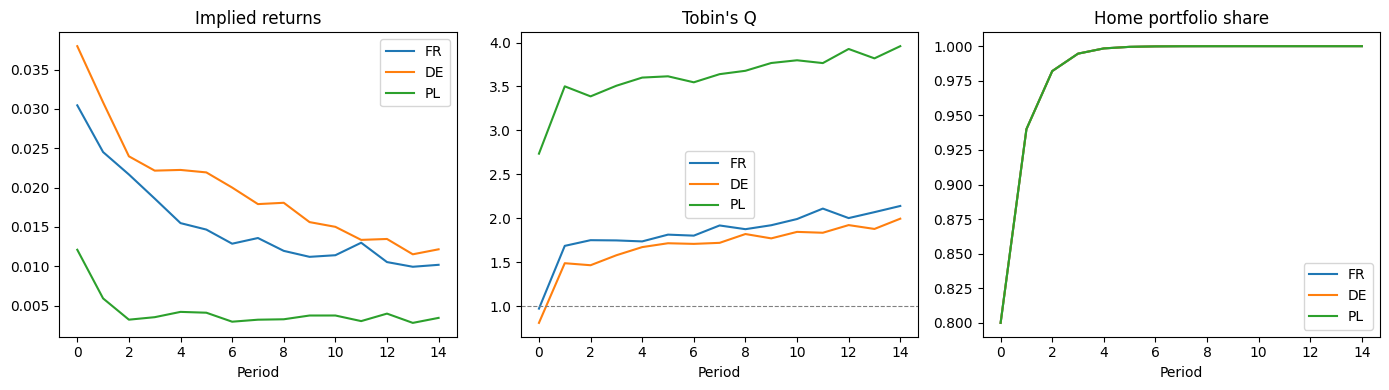

In [14]:
# ── Baseline plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for j, c in enumerate(COUNTRIES):
    axes[0].plot(r_mat[:, j], label=c)
axes[0].set_title("Implied returns")
axes[0].set_xlabel("Period")
axes[0].legend()

for j, c in enumerate(COUNTRIES):
    axes[1].plot(Q_mat[:, j], label=c)
axes[1].axhline(1, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("Tobin's Q")
axes[1].set_xlabel("Period")
axes[1].legend()

for j, c in enumerate(COUNTRIES):
    axes[2].plot(w_home[:, j], label=c)
axes[2].set_title("Home portfolio share")
axes[2].set_xlabel("Period")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Simulate with real data

Plug in the real data, run the simulations and calibrate so they match a given set of objectives.

**Loss function**

We will define a loss function that will give a continuous value which will help us to calibrate. Since we will have mutliple objectvies to optimize, it will measure the score for each and then combine them into one score.

1. $\mathcal{L}_{\text{CPIS}} = 1 - \text{Corr}(\hat{\text{CPIS}}, \text{CPIS})$
2. $\mathcal{L}_{\text{}}$

### Load data

In [15]:
df = pd.read_csv("Data/Clean/Final.csv")
df

,iso3_o,iso3_d,year,distance_km,shared_border,common_legal_origin,language_proximity,language_spoken_share,common_official_language,Index Year_d,...,TFP_o,year_o,Real GDP_d,Capital Stock_d,Worker Population_d,Total Population_d,Labour Share_d,Depreciation Rate_d,TFP_d,year_d
0,ABW,ABW,1997,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1997.0,3531.740967,9336.132812,0.037406,0.081106,0.634907,0.035945,NaN,1997.0
1,ABW,ABW,1998,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1998.0,3767.188477,10134.475586,0.038947,0.083777,0.638232,0.035930,NaN,1998.0
2,ABW,ABW,1999,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1999.0,3810.679932,10909.001953,0.040518,0.086472,0.655211,0.035447,NaN,1999.0
3,ABW,ABW,2000,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,2000.0,3982.696289,11437.366211,0.041918,0.088761,0.645106,0.034938,NaN,2000.0
4,ABW,ABW,2001,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,2001.0,3918.971436,11965.093750,0.042579,0.090305,0.645106,0.034852,NaN,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476220,ZWE,ZWE,2017,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.132940,2017.0,45207.550781,102027.710938,5.204640,14.812482,0.533381,0.057745,1.132940,2017.0
1476221,ZWE,ZWE,2018,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.153515,2018.0,47332.304688,105167.187500,5.235959,15.034452,0.533381,0.059023,1.153515,2018.0
1476222,ZWE,ZWE,2019,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.057740,2019.0,44445.031250,107682.148438,5.272343,15.271368,0.533381,0.059923,1.057740,2019.0
1476223,ZWE,ZWE,2020,42.0,0.0,1.0,NaN,NaN,NaN,NaN,...,0.973187,2020.0,40970.785156,109248.289062,5.206007,15.526888,0.533381,0.060208,0.973187,2020.0


In [16]:
# Feature engineer
df["ln_distance_km"] = np.log(df["distance_km"])
df["ln_cpis"] = np.log(df["cpis"])
df["ln_cpis_t-1"] = np.log(df["cpis_t-1"])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encounter

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476225 entries, 0 to 1476224
Data columns (total 39 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   iso3_o                    1476225 non-null  object 
 1   iso3_d                    1476225 non-null  object 
 2   year                      1476225 non-null  int64  
 3   distance_km               1359650 non-null  float64
 4   shared_border             1359650 non-null  float64
 5   common_legal_origin       1352425 non-null  float64
 6   language_proximity        936050 non-null   float64
 7   language_spoken_share     936050 non-null   float64
 8   common_official_language  936050 non-null   float64
 9   Index Year_d              255150 non-null   float64
 10  Overall Score_d           242757 non-null   float64
 11  Investment Freedom_d      244701 non-null   float64
 12  Financial Freedom_d       244944 non-null   float64
 13  Tax Burden_d              2

### Loss functions

In [18]:
# r2 between cpis and cpis hat
def loss_cpis(cpis, cpis_hat):
    """Inverse, so 1 - r2 since we want to minimise it."""
    return 1 - r2_score(cpis, cpis_hat)

# r2 between rate of returns
def loss_r(r, r_hat):
    """Inverse, so 1 - r2 since we want to minimise it"""
    return 1 - r2_score(r, r_hat)

### Simulation